In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simulacion_ising_no_interactuante(L, T, H, sweeps):
    """
    L: tamaño de la red (L x L)
    T: Temperatura
    H: Campo magnético externo
    sweeps: número de veces que se visita toda la red en promedio
    """
    N = L * L
    # Configuración inicial: red de espines aleatorios (+1 o -1)
    red = np.random.choice([-1, 1], size=(L, L))

    magnetizaciones = []

    for sweep in range(sweeps):
        for _ in range(N):
            # Visitar aleatoriamente un punto
            i, j = np.random.randint(0, L, size=2)
            s_actual = red[i, j]

            # Calcular el cambio de energía si invertimos el espín
            delta_E = 2 * H * s_actual

            # Criterio de Aceptación (Metrópolis)
            if delta_E < 0:
                red[i, j] = -s_actual # Se acepta si la energía disminuye
            else:
                # Factor de Boltzmann
                probabilidad = np.exp(-delta_E / T)
                if np.random.random() <= probabilidad:
                    red[i, j] = -s_actual # Se acepta con probabilidad P

        # Guardamos la magnetización media de este sweep
        mag_media = np.sum(red) / N
        # Evitamos guardar los primeros pasos (termalización)
        if sweep > sweeps // 5:
            magnetizaciones.append(mag_media)

    # Retorna el promedio de la magnetización en equilibrio
    return np.mean(magnetizaciones)

<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2460/897119324.py:31: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('Magnetización Media $\langle M \\rangle$')


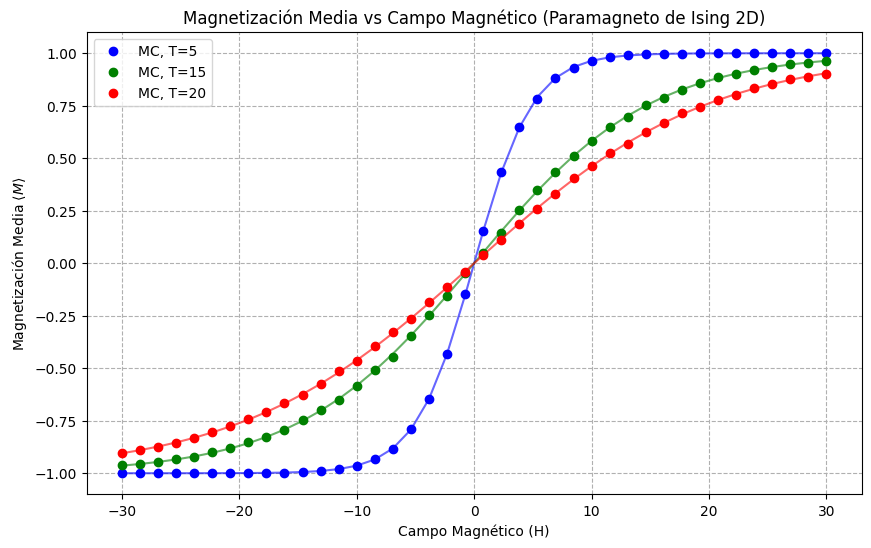

In [2]:
# Parámetros de la simulación
L = 20 # Red de 20x20 = 400 espines
temperaturas = [5, 15, 20]
campos_H = np.linspace(-30, 30, 40)
sweeps_por_punto = 200 # Pasos de Monte Carlo por cada valor de H

plt.figure(figsize=(10, 6))

# Colores para graficar
colores = ['b', 'g', 'r']

for T, color in zip(temperaturas, colores):
    mag_simulada = []
    mag_analitica = []

    for H in campos_H:
        # Simulacion MC
        m = simulacion_ising_no_interactuante(L, T, H, sweeps_por_punto)
        mag_simulada.append(m)

        # Resultado analítico
        mag_analitica.append(np.tanh(H / T))

    # Graficar puntos de simulación
    plt.plot(campos_H, mag_simulada, 'o', color=color, label=f'MC, T={T}')
    # Graficar línea de teoría analítica
    plt.plot(campos_H, mag_analitica, '-', color=color, alpha=0.6)

plt.title('Magnetización Media vs Campo Magnético (Paramagneto de Ising 2D)')
plt.xlabel('Campo Magnético (H)')
plt.ylabel('Magnetización Media $\langle M \\rangle$')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()



Para un sistema de $N$ espines no interactuantes que solo sienten el campo externo $H$, el sistema se puede tratar calculando la función de partición de un solo espín $Z_1$.
Los estados posibles de un espín son $+1$ (alineado con $H$) y $-1$ (antialineado). Sus energías son $-H$ y $+H$ (en unidades donde $\mu_0=1$).

La función de partición es:


$$Z_1 = e^{H/T} + e^{-H/T} = 2\cosh(H/T)$$

El valor esperado del espín (magnetización por partícula) se calcula derivando $\ln Z_1$ o aplicando la suma ponderada por las probabilidades:


$$\langle s \rangle = \frac{(+1)e^{H/T} + (-1)e^{-H/T}}{e^{H/T} + e^{-H/T}} = \frac{2\sinh(H/T)}{2\cosh(H/T)} = \tanh\left(\frac{H}{T}\right)$$

La magnetización total sería $\langle M_{total} \rangle = N \tanh(H/T)$, y la magnetización media por átomo es simplemente **$\tanh(H/T)$**.

En las graficas se ve que los puntos de la simulación (círculos) caen sobre las líneas teóricas ($\tanh(H/T)$).



Se observa Convergencia de la Cadena de Markov (MCMC). El algoritmo de Metrópolis asegura que, tras suficientes pasos (termalización), los microestados visitados se distribuyen idénticamente a la distribución canónica de Boltzmann $\mathcal{P} \propto e^{-E/T}$.
También en ausencia de interacciones entre espines ($J=0$), no hay efectos colectivos complejos como transiciones de fase (que ocurren en el modelo de Ising tradicional). Cada espín actúa como un sistema independiente, lo que reduce el ruido estadístico y hace que el muestreo converja muy rápido hacia el valor analítico.